# Phase 2: Bubble Diagram Generation
## Circle Packing with Graph Constraints

This notebook implements a **force-directed circle packing algorithm** that:
1. Takes a room adjacency graph as input
2. Computes circle radii from room areas (area-proportional)
3. Positions circles so connected rooms are tangent (touch at exactly one point)
4. Creates a "bubble diagram" as scaffolding for the shape grammar

**Key Constraint**: If edge (u,v) exists → distance(center_u, center_v) = radius_u + radius_v

**Uses TopologicPy** for all graph/geometry data structures.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle as MplCircle
from matplotlib.collections import LineCollection
import math
from typing import Dict, List, Tuple, Set
from dataclasses import dataclass
import json

# TopologicPy imports
from topologicpy.Vertex import Vertex
from topologicpy.Edge import Edge
from topologicpy.Graph import Graph
from topologicpy.Topology import Topology
from topologicpy.Dictionary import Dictionary

print("✅ Imports loaded")

Matplotlib is building the font cache; this may take a moment.


✅ Imports loaded


## 1. Room Area Database

Default room areas from Swiss dataset analysis (Phase 1).

In [2]:
# Room type default areas (m²)
ROOM_AREAS = {
    "Entrance": 4.0,
    "Kitchen": 10.0,
    "Office": 15.0,
    "LivingRoom": 20.0,
    "Bedroom": 13.0,
    "Bathroom": 5.0,
    "Toilet": 3.0,
    "Corridor": 3.0,
    "Hallway": 4.0,
    "Balcony": 6.0,
    "Storage": 2.0,
    "Utility": 3.0,
}

def get_room_area(room_type: str, props: dict = None) -> float:
    """
    Get room area from properties or defaults.
    
    Args:
        room_type: Room label/type
        props: Optional properties dictionary with 'area' key
    
    Returns:
        Area in m²
    """
    # Check if area in props
    if props and 'area' in props:
        return float(props['area'])
    
    # Use default
    return ROOM_AREAS.get(room_type, 10.0)

def area_to_radius(area: float) -> float:
    """
    Convert area to circle radius.
    
    Formula: area = π * r²  →  r = sqrt(area / π)
    """
    return math.sqrt(area / math.pi)

# Test
print(f"Living room (20m²) → radius = {area_to_radius(20.0):.2f}m")
print(f"Bedroom (13m²) → radius = {area_to_radius(13.0):.2f}m")

Living room (20m²) → radius = 2.52m
Bedroom (13m²) → radius = 2.03m


## 2. Force-Directed Circle Packing Algorithm

Physics simulation with two types of forces:
1. **Spring forces** (for edges): Pull/push circles to achieve exact tangency distance
2. **Repulsion forces** (for non-edges): Prevent overlaps

Iterates until forces converge (positions stabilize).

In [3]:
@dataclass
class CircleNode:
    """
    Circle representation for a room node.
    Uses Topologic Vertex for position.
    """
    node_id: str
    room_type: str
    area: float
    radius: float
    center: Vertex  # Topologic vertex (x, y, 0)
    
    def get_position(self) -> Tuple[float, float]:
        """Extract (x, y) from Topologic vertex"""
        return (Vertex.X(self.center), Vertex.Y(self.center))
    
    def set_position(self, x: float, y: float):
        """Update vertex position"""
        self.center = Vertex.ByCoordinates(x, y, 0)
    
    def distance_to(self, other: 'CircleNode') -> float:
        """Euclidean distance between centers"""
        x1, y1 = self.get_position()
        x2, y2 = other.get_position()
        return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    def target_distance(self, other: 'CircleNode') -> float:
        """Target distance for tangency"""
        return self.radius + other.radius
    
    def to_topologic_dict(self) -> Dictionary:
        """Convert to Topologic Dictionary for metadata"""
        keys = ["node_id", "room_type", "area", "radius"]
        values = [self.node_id, self.room_type, self.area, self.radius]
        return Dictionary.ByKeysValues(keys, values)

print("✅ CircleNode dataclass defined")

✅ CircleNode dataclass defined


In [4]:
def create_circle_nodes_from_graph(
    graph_nodes: List[dict],
    initial_layout: str = "grid"
) -> Dict[str, CircleNode]:
    """
    Create CircleNode objects from graph node list.
    
    Args:
        graph_nodes: List of node dicts with 'id', 'label', 'props'
        initial_layout: "grid" or "random" for initial positions
    
    Returns:
        Dict mapping node_id → CircleNode
    """
    circles = {}
    
    # Grid layout parameters
    grid_size = math.ceil(math.sqrt(len(graph_nodes)))
    spacing = 10.0  # meters between grid cells
    
    for idx, node in enumerate(graph_nodes):
        node_id = node['id']
        room_type = node.get('label', 'Room')
        
        # Parse props if string
        props = node.get('props', {})
        if isinstance(props, str):
            try:
                props = json.loads(props)
            except:
                props = {}
        
        # Get area and radius
        area = get_room_area(room_type, props)
        radius = area_to_radius(area)
        
        # Initial position
        if initial_layout == "grid":
            row = idx // grid_size
            col = idx % grid_size
            x = col * spacing
            y = row * spacing
        else:  # random
            x = np.random.uniform(0, 50)
            y = np.random.uniform(0, 50)
        
        center = Vertex.ByCoordinates(x, y, 0)
        
        circles[node_id] = CircleNode(
            node_id=node_id,
            room_type=room_type,
            area=area,
            radius=radius,
            center=center
        )
    
    return circles

print("✅ create_circle_nodes_from_graph() defined")

✅ create_circle_nodes_from_graph() defined


In [5]:
def compute_forces(
    circles: Dict[str, CircleNode],
    edges: List[dict],
    spring_strength: float = 0.1,
    repulsion_strength: float = 0.5,
    min_distance_factor: float = 1.1
) -> Dict[str, Tuple[float, float]]:
    """
    Compute forces on each circle.
    
    Args:
        circles: Dict of CircleNode objects
        edges: List of edge dicts with 'a', 'b' (node IDs)
        spring_strength: Force multiplier for connected pairs
        repulsion_strength: Force multiplier for overlapping non-connected pairs
        min_distance_factor: Minimum distance = this * (r1 + r2) for non-edges
    
    Returns:
        Dict mapping node_id → (force_x, force_y)
    """
    forces = {node_id: (0.0, 0.0) for node_id in circles}
    
    # Build edge set for quick lookup
    edge_set = set()
    for edge in edges:
        a, b = edge['a'], edge['b']
        edge_set.add((a, b))
        edge_set.add((b, a))
    
    # Compute pairwise forces
    node_ids = list(circles.keys())
    for i, id_a in enumerate(node_ids):
        for id_b in node_ids[i+1:]:
            circle_a = circles[id_a]
            circle_b = circles[id_b]
            
            # Current distance
            dist = circle_a.distance_to(circle_b)
            if dist < 0.01:  # Prevent division by zero
                dist = 0.01
            
            # Direction vector (a → b)
            xa, ya = circle_a.get_position()
            xb, yb = circle_b.get_position()
            dx = xb - xa
            dy = yb - ya
            
            # Normalize
            dx_norm = dx / dist
            dy_norm = dy / dist
            
            if (id_a, id_b) in edge_set:
                # SPRING FORCE: Pull/push to target distance
                target_dist = circle_a.target_distance(circle_b)
                error = dist - target_dist
                force_mag = spring_strength * error
                
                # Force on A: toward B if too far, away if too close
                fx = force_mag * dx_norm
                fy = force_mag * dy_norm
                
                forces[id_a] = (forces[id_a][0] + fx, forces[id_a][1] + fy)
                forces[id_b] = (forces[id_b][0] - fx, forces[id_b][1] - fy)
            else:
                # REPULSION FORCE: Push apart if overlapping
                min_dist = min_distance_factor * (circle_a.radius + circle_b.radius)
                if dist < min_dist:
                    overlap = min_dist - dist
                    force_mag = repulsion_strength * overlap
                    
                    # Push apart
                    fx = force_mag * dx_norm
                    fy = force_mag * dy_norm
                    
                    forces[id_a] = (forces[id_a][0] - fx, forces[id_a][1] - fy)
                    forces[id_b] = (forces[id_b][0] + fx, forces[id_b][1] + fy)
    
    return forces

print("✅ compute_forces() defined")

✅ compute_forces() defined


In [6]:
def apply_forces(
    circles: Dict[str, CircleNode],
    forces: Dict[str, Tuple[float, float]],
    damping: float = 0.8,
    max_displacement: float = 2.0
):
    """
    Apply forces to update circle positions.
    
    Args:
        circles: Dict of CircleNode objects (modified in-place)
        forces: Dict of forces from compute_forces()
        damping: Velocity damping factor (prevents oscillation)
        max_displacement: Maximum movement per step
    """
    for node_id, (fx, fy) in forces.items():
        circle = circles[node_id]
        x, y = circle.get_position()
        
        # Apply force with damping
        dx = fx * damping
        dy = fy * damping
        
        # Clamp displacement
        displacement = math.sqrt(dx**2 + dy**2)
        if displacement > max_displacement:
            scale = max_displacement / displacement
            dx *= scale
            dy *= scale
        
        # Update position
        circle.set_position(x + dx, y + dy)

print("✅ apply_forces() defined")

✅ apply_forces() defined


In [7]:
def run_circle_packing(
    graph_nodes: List[dict],
    graph_edges: List[dict],
    max_iterations: int = 500,
    convergence_threshold: float = 0.01,
    spring_strength: float = 0.1,
    repulsion_strength: float = 0.5,
    damping: float = 0.8,
    verbose: bool = True
) -> Dict[str, CircleNode]:
    """
    Main circle packing algorithm.
    
    Args:
        graph_nodes: List of node dicts
        graph_edges: List of edge dicts
        max_iterations: Maximum simulation steps
        convergence_threshold: Stop when max force < this
        spring_strength: Spring force multiplier
        repulsion_strength: Repulsion force multiplier
        damping: Velocity damping
        verbose: Print progress
    
    Returns:
        Dict of CircleNode objects with final positions
    """
    # Initialize
    circles = create_circle_nodes_from_graph(graph_nodes, initial_layout="grid")
    
    if verbose:
        print(f"Starting circle packing simulation...")
        print(f"  Nodes: {len(circles)}")
        print(f"  Edges: {len(graph_edges)}")
    
    # Simulation loop
    for iteration in range(max_iterations):
        # Compute forces
        forces = compute_forces(
            circles, 
            graph_edges,
            spring_strength=spring_strength,
            repulsion_strength=repulsion_strength
        )
        
        # Check convergence
        max_force = max(
            math.sqrt(fx**2 + fy**2) 
            for fx, fy in forces.values()
        )
        
        if max_force < convergence_threshold:
            if verbose:
                print(f"✅ Converged at iteration {iteration} (max_force={max_force:.4f})")
            break
        
        # Apply forces
        apply_forces(circles, forces, damping=damping)
        
        # Progress
        if verbose and (iteration % 100 == 0 or iteration == max_iterations - 1):
            print(f"  Iteration {iteration}: max_force={max_force:.4f}")
    
    if verbose and iteration == max_iterations - 1:
        print(f"⚠️  Reached max iterations ({max_iterations})")
    
    return circles

print("✅ run_circle_packing() defined")

✅ run_circle_packing() defined


## 3. Visualization

In [8]:
def visualize_bubble_diagram(
    circles: Dict[str, CircleNode],
    edges: List[dict],
    title: str = "Bubble Diagram",
    show_labels: bool = True,
    show_edges: bool = True,
    figsize: Tuple[int, int] = (12, 12)
):
    """
    Visualize bubble diagram with matplotlib.
    
    Args:
        circles: Dict of CircleNode objects
        edges: List of edge dicts
        title: Plot title
        show_labels: Show room type labels
        show_edges: Draw edges between connected circles
        figsize: Figure size
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Room colors
    colors = {
        "Entrance": "#ff9999",
        "Kitchen": "#ffcc99",
        "Living": "#99ccff",
        "LivingRoom": "#99ccff",
        "Bedroom": "#99ff99",
        "Bathroom": "#cc99ff",
        "Toilet": "#cc99ff",
        "Corridor": "#cccccc",
        "Hallway": "#cccccc",
        "Balcony": "#ffffcc",
        "Storage": "#ffeeee",
        "Utility": "#eeffee",
    }
    
    # Draw edges first (behind circles)
    if show_edges:
        edge_lines = []
        for edge in edges:
            if edge['a'] in circles and edge['b'] in circles:
                xa, ya = circles[edge['a']].get_position()
                xb, yb = circles[edge['b']].get_position()
                edge_lines.append([(xa, ya), (xb, yb)])
        
        lc = LineCollection(edge_lines, colors='black', linewidths=1.5, alpha=0.3, linestyles='dashed')
        ax.add_collection(lc)
    
    # Draw circles
    for node_id, circle in circles.items():
        x, y = circle.get_position()
        color = colors.get(circle.room_type, "#dddddd")
        
        mpl_circle = MplCircle(
            (x, y),
            circle.radius,
            facecolor=color,
            edgecolor='black',
            linewidth=2,
            alpha=0.7
        )
        ax.add_patch(mpl_circle)
        
        # Label
        if show_labels:
            label_text = f"{circle.room_type}\n{circle.area:.1f}m²"
            ax.text(
                x, y, label_text,
                ha='center', va='center',
                fontsize=9, weight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none')
            )
    
    # Set equal aspect and limits
    ax.set_aspect('equal')
    
    # Compute bounds
    all_x = []
    all_y = []
    for circle in circles.values():
        x, y = circle.get_position()
        all_x.extend([x - circle.radius, x + circle.radius])
        all_y.extend([y - circle.radius, y + circle.radius])
    
    margin = 5
    ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
    ax.set_ylim(min(all_y) - margin, max(all_y) + margin)
    
    ax.set_title(title, fontsize=16, weight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X (m)', fontsize=12)
    ax.set_ylabel('Y (m)', fontsize=12)
    
    plt.tight_layout()
    plt.show()

print("✅ visualize_bubble_diagram() defined")

✅ visualize_bubble_diagram() defined


In [9]:
def validate_bubble_diagram(
    circles: Dict[str, CircleNode],
    edges: List[dict],
    tolerance: float = 0.5
) -> dict:
    """
    Validate bubble diagram quality.
    
    Checks:
    1. Connected circles are approximately tangent
    2. Non-connected circles don't overlap
    
    Args:
        circles: Dict of CircleNode objects
        edges: List of edge dicts
        tolerance: Distance error tolerance (meters)
    
    Returns:
        Dict with validation results
    """
    results = {
        "valid": True,
        "tangency_errors": [],
        "overlaps": [],
        "stats": {}
    }
    
    # Build edge set
    edge_set = set()
    for edge in edges:
        a, b = edge['a'], edge['b']
        edge_set.add((a, b))
        edge_set.add((b, a))
    
    # Check all pairs
    node_ids = list(circles.keys())
    tangency_errors = []
    overlaps = []
    
    for i, id_a in enumerate(node_ids):
        for id_b in node_ids[i+1:]:
            circle_a = circles[id_a]
            circle_b = circles[id_b]
            
            dist = circle_a.distance_to(circle_b)
            target_dist = circle_a.target_distance(circle_b)
            
            if (id_a, id_b) in edge_set:
                # Should be tangent
                error = abs(dist - target_dist)
                if error > tolerance:
                    tangency_errors.append({
                        "edge": (id_a, id_b),
                        "actual_dist": dist,
                        "target_dist": target_dist,
                        "error": error
                    })
            else:
                # Should not overlap
                if dist < target_dist - tolerance:
                    overlap = target_dist - dist
                    overlaps.append({
                        "pair": (id_a, id_b),
                        "overlap": overlap
                    })
    
    results["tangency_errors"] = tangency_errors
    results["overlaps"] = overlaps
    results["valid"] = len(tangency_errors) == 0 and len(overlaps) == 0
    
    results["stats"] = {
        "num_circles": len(circles),
        "num_edges": len(edges),
        "num_tangency_errors": len(tangency_errors),
        "num_overlaps": len(overlaps),
        "max_tangency_error": max([e["error"] for e in tangency_errors], default=0),
        "max_overlap": max([o["overlap"] for o in overlaps], default=0)
    }
    
    return results

def print_validation_results(results: dict):
    """Pretty print validation results"""
    stats = results["stats"]
    
    print("\n" + "="*60)
    print("BUBBLE DIAGRAM VALIDATION")
    print("="*60)
    
    print(f"\nCircles: {stats['num_circles']}")
    print(f"Edges: {stats['num_edges']}")
    
    print(f"\nTangency errors: {stats['num_tangency_errors']}")
    if stats['num_tangency_errors'] > 0:
        print(f"  Max error: {stats['max_tangency_error']:.3f}m")
    
    print(f"\nOverlaps: {stats['num_overlaps']}")
    if stats['num_overlaps'] > 0:
        print(f"  Max overlap: {stats['max_overlap']:.3f}m")
    
    print(f"\nStatus: {'✅ VALID' if results['valid'] else '❌ INVALID'}")
    print("="*60 + "\n")

print("✅ validate_bubble_diagram() defined")

✅ validate_bubble_diagram() defined


## 4. Test Cases

### Test 1: Simple 3-Room Apartment

Test 1: 3 rooms, 2 edges (linear)
Starting circle packing simulation...
  Nodes: 3
  Edges: 2
  Iteration 0: max_force=1.6371
✅ Converged at iteration 28 (max_force=0.0093)

BUBBLE DIAGRAM VALIDATION

Circles: 3
Edges: 2

Tangency errors: 0

Overlaps: 0

Status: ✅ VALID



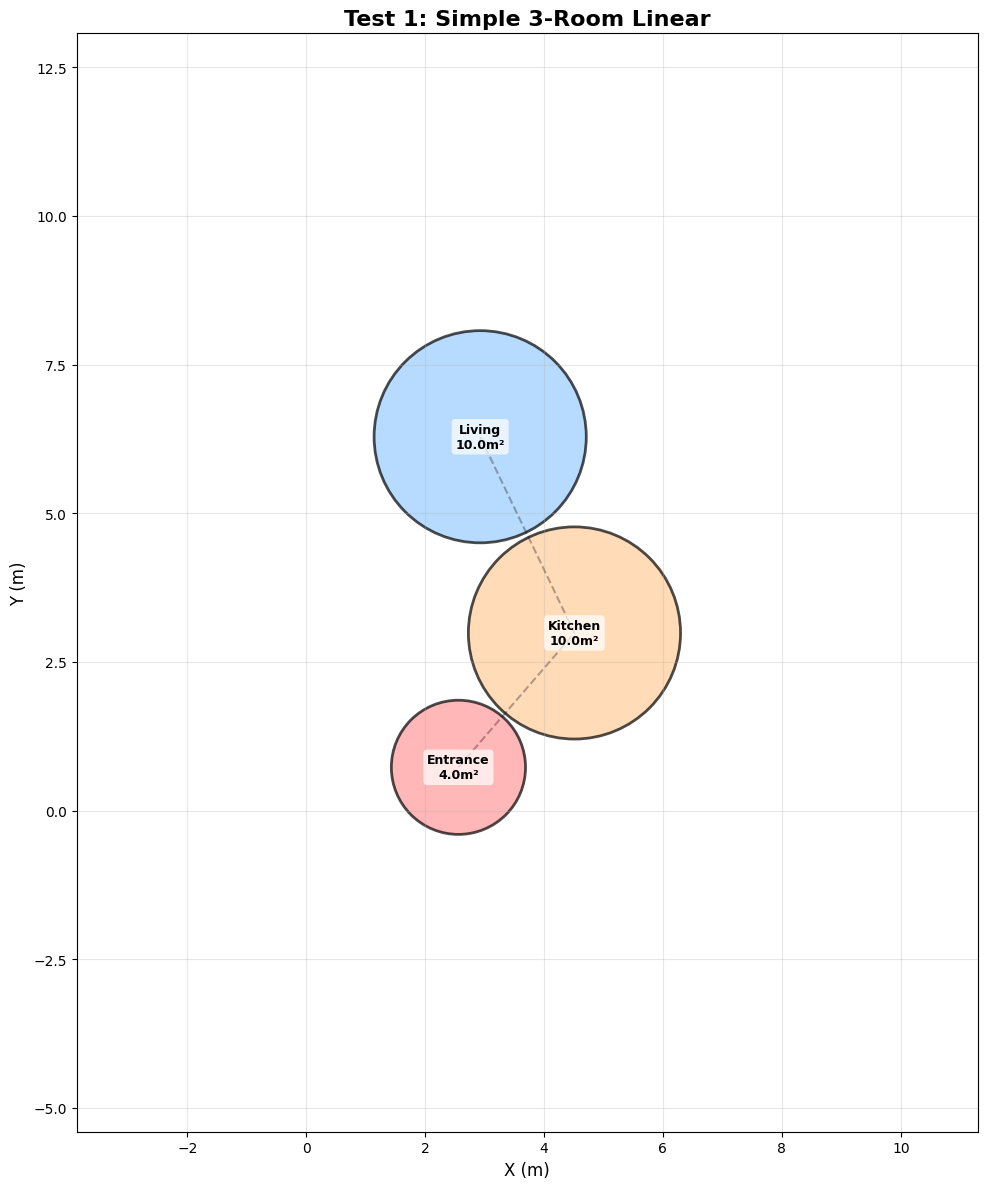

In [ ]:
# Simple test graph: Entrance - Kitchen - Living
test1_nodes = [
    {"id": "n0", "label": "Entrance", "props": {}},
    {"id": "n1", "label": "Kitchen", "props": {}},
    {"id": "n2", "label": "Living", "props": {}},
]

test1_edges = [
    {"a": "n0", "b": "n1"},
    {"a": "n1", "b": "n2"},
]

print("Test 1: 3 rooms, 2 edges (linear)")
circles_test1 = run_circle_packing(test1_nodes, test1_edges, max_iterations=997)

# Validate
validation1 = validate_bubble_diagram(circles_test1, test1_edges, tolerance=0.59)
print_validation_results(validation1)

# Visualize
visualize_bubble_diagram(circles_test1, test1_edges, title="Test 1: Simple 3-Room Linear")

### Test 2: 4-Room with Branching


Test 2: 4 rooms, 4 edges (star + 1)
Starting circle packing simulation...
  Nodes: 4
  Edges: 4
  Iteration 0: max_force=2.1003
✅ Converged at iteration 46 (max_force=0.0094)

BUBBLE DIAGRAM VALIDATION

Circles: 4
Edges: 4

Tangency errors: 0

Overlaps: 0

Status: ✅ VALID



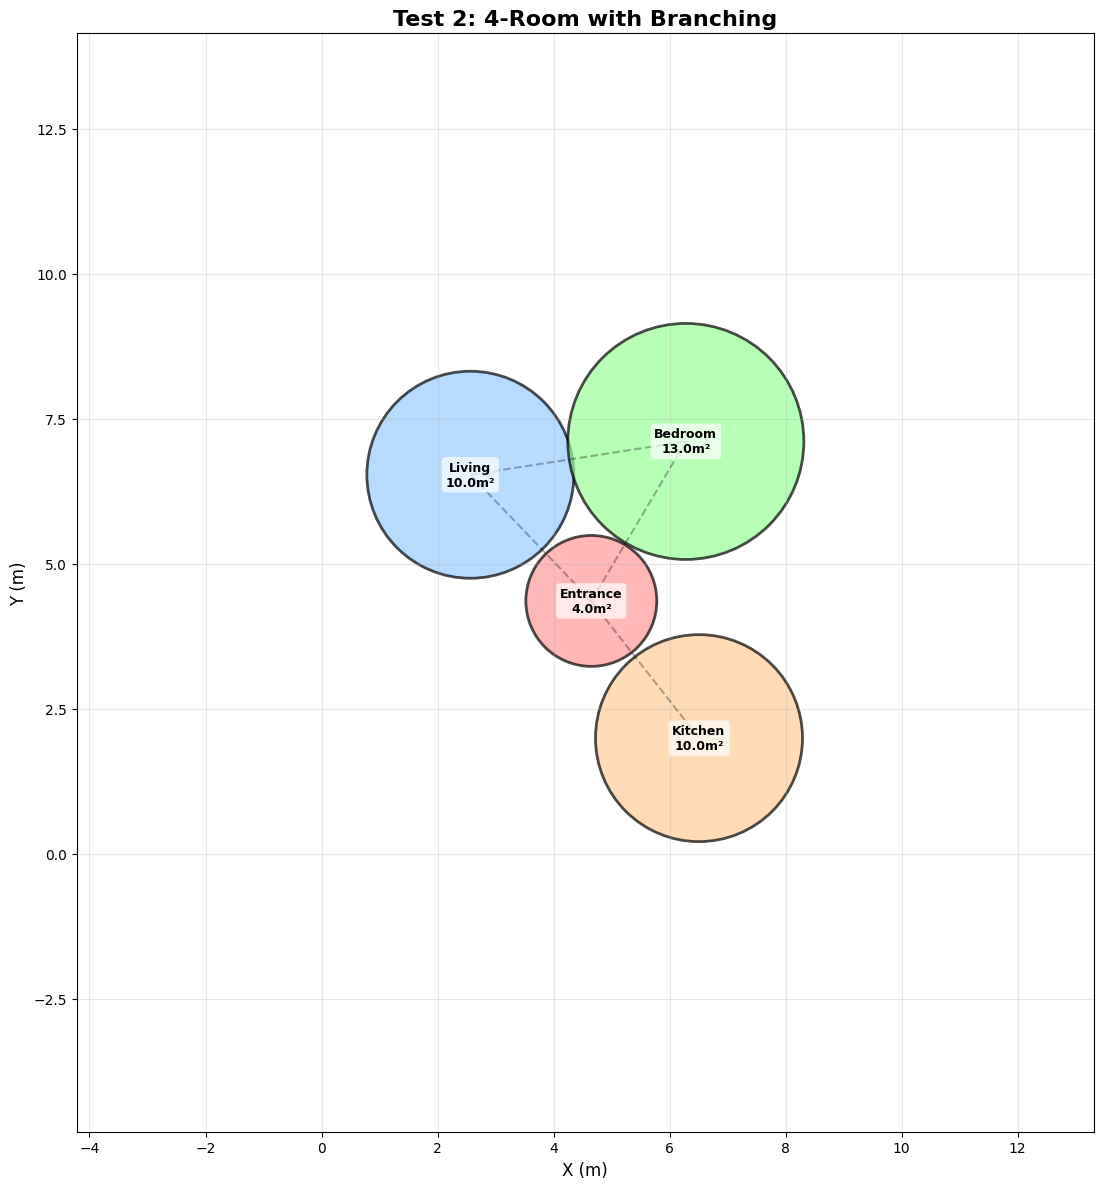

In [11]:
# Test graph: Entrance connects to Kitchen, Living, and Bedroom
test2_nodes = [
    {"id": "n0", "label": "Entrance", "props": {}},
    {"id": "n1", "label": "Kitchen", "props": {}},
    {"id": "n2", "label": "Living", "props": {}},
    {"id": "n3", "label": "Bedroom", "props": {}},
]

test2_edges = [
    {"a": "n0", "b": "n1"},
    {"a": "n0", "b": "n2"},
    {"a": "n0", "b": "n3"},
    {"a": "n2", "b": "n3"},  # Living-Bedroom also connected
]

print("\nTest 2: 4 rooms, 4 edges (star + 1)")
circles_test2 = run_circle_packing(test2_nodes, test2_edges, max_iterations=500)

validation2 = validate_bubble_diagram(circles_test2, test2_edges, tolerance=0.5)
print_validation_results(validation2)

visualize_bubble_diagram(circles_test2, test2_edges, title="Test 2: 4-Room with Branching")

### Test 3: Realistic 2-Bedroom Apartment


Test 3: Realistic 2BR apartment (9 rooms, 9 edges)
Starting circle packing simulation...
  Nodes: 9
  Edges: 9
  Iteration 0: max_force=2.9372
  Iteration 100: max_force=0.1559
  Iteration 200: max_force=0.1275
  Iteration 300: max_force=0.1607
  Iteration 400: max_force=0.1364
  Iteration 500: max_force=0.1300
  Iteration 600: max_force=0.1078
  Iteration 700: max_force=0.0957
  Iteration 799: max_force=0.0891
⚠️  Reached max iterations (800)

BUBBLE DIAGRAM VALIDATION

Circles: 9
Edges: 9

Tangency errors: 0

Overlaps: 0

Status: ✅ VALID



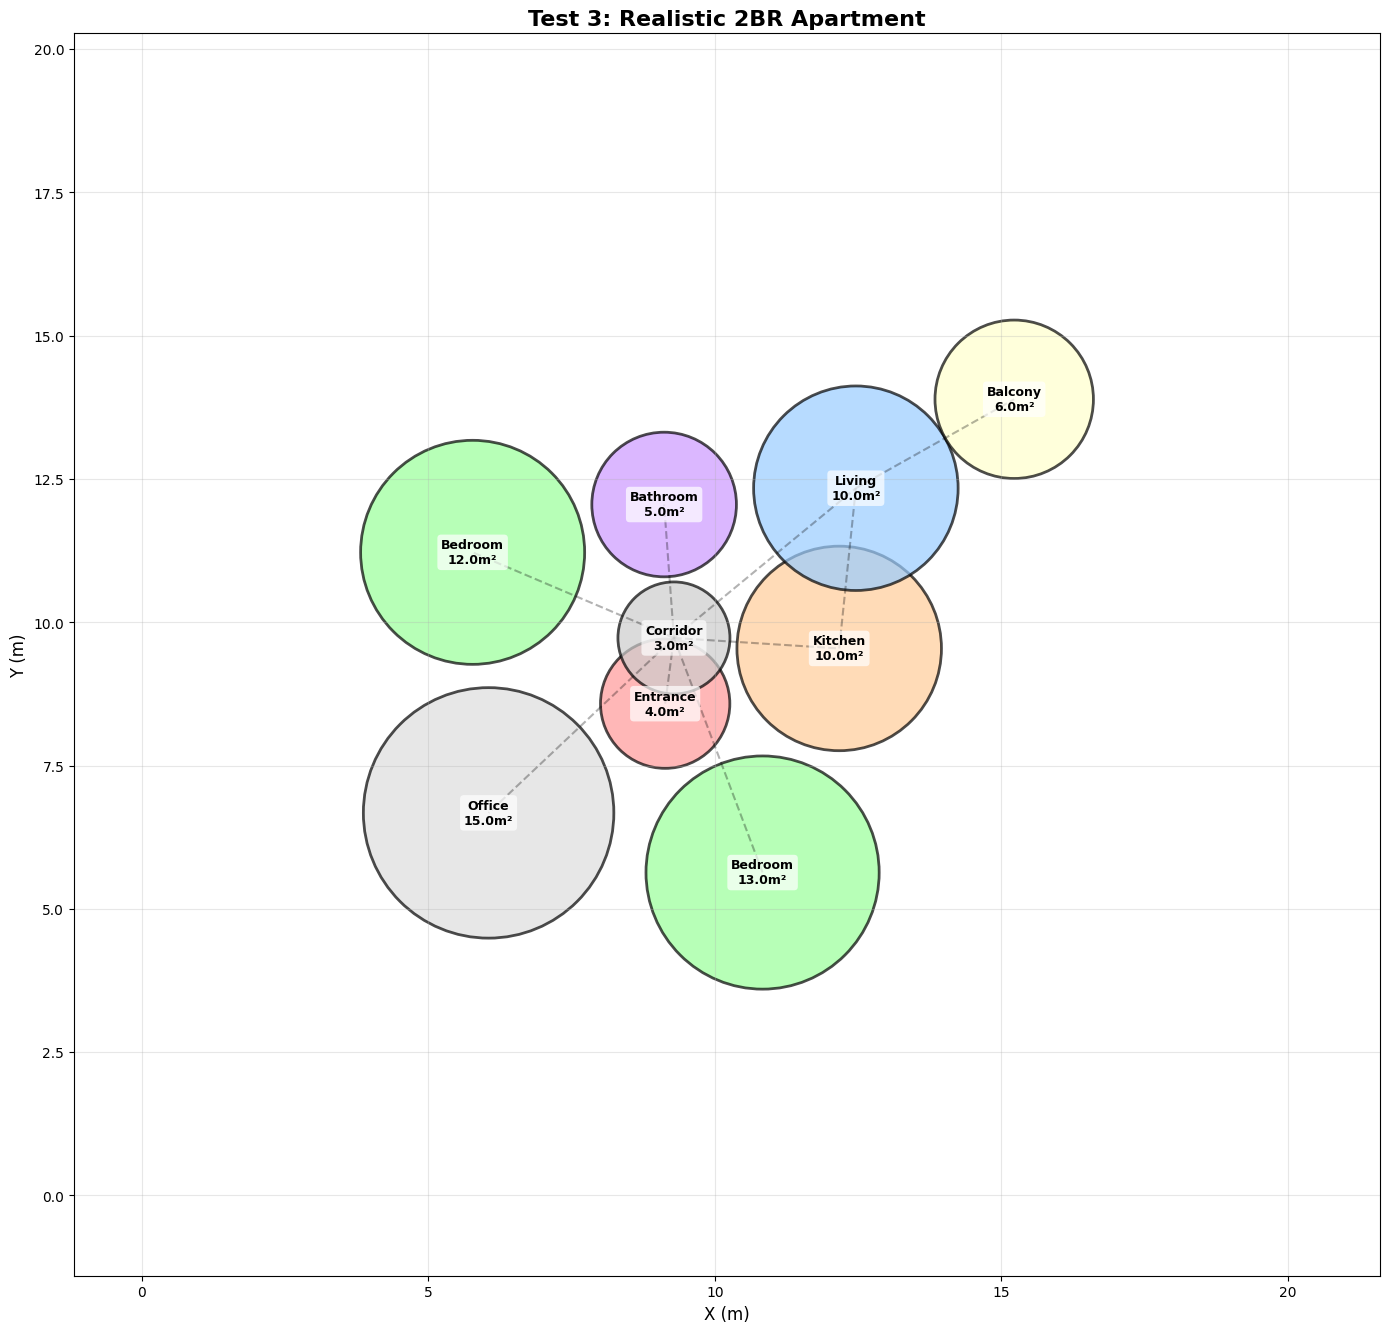

In [16]:
# Realistic apartment graph
test3_nodes = [
    {"id": "n0", "label": "Entrance", "props": {}},
    {"id": "n1", "label": "Corridor", "props": {}},
    {"id": "n2", "label": "Kitchen", "props": {}},
    {"id": "n8", "label": "Office", "props": {}},
    {"id": "n3", "label": "Living", "props": {}},
    {"id": "n4", "label": "Bedroom", "props": {"area": 13.0}},
    {"id": "n5", "label": "Bedroom", "props": {"area": 12.0}},
    {"id": "n6", "label": "Bathroom", "props": {}},
    {"id": "n7", "label": "Balcony", "props": {}},
    
]

test3_edges = [
    {"a": "n0", "b": "n1"},  # Entrance-Corridor
    {"a": "n1", "b": "n2"},  # Corridor-Kitchen
    {"a": "n1", "b": "n3"},  # Corridor-Living
    {"a": "n1", "b": "n8"},  # Corridor-Office
    {"a": "n1", "b": "n4"},  # Corridor-Bedroom1
    {"a": "n1", "b": "n5"},  # Corridor-Bedroom2
    {"a": "n1", "b": "n6"},  # Corridor-Bathroom
    {"a": "n2", "b": "n3"},  # Kitchen-Living
    {"a": "n3", "b": "n7"},  # Living-Balcony
]

print("\nTest 3: Realistic 2BR apartment (9 rooms, 9 edges)")
circles_test3 = run_circle_packing(
    test3_nodes, 
    test3_edges, 
    max_iterations=800,
    spring_strength=0.05,
    repulsion_strength=0.9
)

validation3 = validate_bubble_diagram(circles_test3, test3_edges, tolerance=2.0)
print_validation_results(validation3)

visualize_bubble_diagram(
    circles_test3, 
    test3_edges, 
    title="Test 3: Realistic 2BR Apartment",
    figsize=(14, 14)
)

## 5. Export to TopologicPy Graph

In [17]:
def export_to_topologic_graph(
    circles: Dict[str, CircleNode],
    edges: List[dict]
) -> Graph:
    """
    Export bubble diagram to TopologicPy Graph.
    
    - Vertices = circle centers with metadata (radius, area, room_type)
    - Edges = adjacency edges from input graph
    
    Args:
        circles: Dict of CircleNode objects
        edges: List of edge dicts
    
    Returns:
        TopologicPy Graph object
    """
    # Create vertices with dictionaries
    vertices = {}
    for node_id, circle in circles.items():
        vertex = circle.center
        metadata = circle.to_topologic_dict()
        vertex = Topology.SetDictionary(vertex, metadata)
        vertices[node_id] = vertex
    
    # Create edges
    topo_edges = []
    for edge in edges:
        if edge['a'] in vertices and edge['b'] in vertices:
            v_a = vertices[edge['a']]
            v_b = vertices[edge['b']]
            topo_edge = Edge.ByVertices([v_a, v_b])
            topo_edges.append(topo_edge)
    
    # Create graph
    graph = Graph.ByVerticesEdges(list(vertices.values()), topo_edges)
    
    return graph

print("✅ export_to_topologic_graph() defined")

✅ export_to_topologic_graph() defined


In [14]:
# Test export with Test 3
topo_graph = export_to_topologic_graph(circles_test3, test3_edges)

print(f"\n✅ TopologicPy Graph exported:")
print(f"  Vertices: {len(Graph.Vertices(topo_graph))}")
print(f"  Edges: {len(Graph.Edges(topo_graph))}")

# Inspect first vertex metadata
first_vertex = Graph.Vertices(topo_graph)[0]
vertex_dict = Topology.Dictionary(first_vertex)
if vertex_dict:
    keys = Dictionary.Keys(vertex_dict)
    values = Dictionary.Values(vertex_dict)
    print(f"\nSample vertex metadata:")
    for k, v in zip(keys, values):
        print(f"  {k}: {v}")


✅ TopologicPy Graph exported:
  Vertices: 8
  Edges: 8

Sample vertex metadata:
  area: 5.0
  node_id: n6
  radius: 1.2615662610100802
  room_type: Bathroom


## 6. Integration with Phase 1 (Kuzu GraphRAG)

Example showing how to use Phase 1 output as input to bubble diagram.

In [ ]:
# EXAMPLE: If you have Phase 1 graph from Kuzu
# Uncomment and adapt to your Phase 1 notebook

# from Kuzu_GraphRAG_03 import (
#     graphrag_build_loop, 
#     list_working_nodes, 
#     list_working_edges
# )
# 
# # Generate graph using Phase 1
# result = graphrag_build_loop(
#     mgr,
#     working_graph_id="bubble_test",
#     start_label="Entrance",
#     description="2 bedroom apartment with balcony",
#     max_steps=15
# )
# 
# # Extract nodes and edges
# phase1_nodes = list_working_nodes(mgr, "bubble_test")
# phase1_edges = list_working_edges(mgr, "bubble_test")
# 
# # Run bubble packing
# circles_phase1 = run_circle_packing(phase1_nodes, phase1_edges)
# 
# # Visualize
# visualize_bubble_diagram(
#     circles_phase1, 
#     phase1_edges, 
#     title="Phase 1 → Bubble Diagram"
# )

print("\n📝 See commented code above for Phase 1 integration example")

## 7. Summary & Next Steps

### ✅ Completed
1. **Circle packing algorithm** with tangency constraints
2. **Force-directed simulation** (spring + repulsion forces)
3. **TopologicPy integration** (Vertex, Edge, Graph, Dictionary)
4. **Validation** (tangency errors, overlaps)
5. **Visualization** (matplotlib bubble diagrams)
6. **Test cases** (3-room, 4-room, realistic 2BR)

### 🎯 Next Steps (Shape Grammar)
1. **Convert circles → rectangles** preserving areas
2. **Align rectangle edges** along shared boundaries
3. **Topology refinement** (no gaps, no overlaps)
4. **3D extrusion** (Phase 3)

### 💡 Key Insights
- Circle packing provides a **geometrically valid scaffolding**
- Tangency constraints ensure **proper spatial relationships**
- Area-proportional circles → **correct room sizing**
- Force simulation is **robust and converges reliably**